# Resume Screening using LLMs

In [1]:
!pip -q install datasets transformers sentencepiece evaluate scikit-learn sentence-transformers faiss-cpu bitsandbytes accelerate nltk scipy

import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, f1_score

import evaluate
import nltk
nltk.download("punkt")

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
)

from sentence_transformers import SentenceTransformer
import faiss

SEED = 42
set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
os.environ["TOKENIZERS_PARALLELISM"] = "false"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 77.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 32.2 MB/s eta 0:00:00:00:0100:01


2025-12-21 03:50:27.594058: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766289027.789442      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766289027.847102      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766289028.310887      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766289028.310924      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766289028.310927      55 computation_placer.cc:177] computation placer alr

Device: cuda


In [2]:

import seaborn as sns

# Publication-friendly plotting defaults
sns.set(style="whitegrid", context="paper")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 10


## 1) Data Collection

In [3]:

dataset = load_dataset("ganchengguang/resume_seven_class", token=os.getenv("HUGGINGFACE_HUB_TOKEN", None))
df = pd.DataFrame(dataset["train"])

prefix_map = {
    "PI": "personal information",
    "Exp": "experience",
    "Sum": "summary",
    "Edu": "education",
    "Cer": "qualification certification",
    "QC":  "qualification certification",
    "Ski": "skill",
    "Skill": "skill",
    "Obj": "objectives",
}
def extract_label(text: str) -> str:
    if not isinstance(text, str) or text.strip()=="":
        return "unknown"
    prefix = text.split()[0].replace(":", "").replace("|","").strip()
    return prefix_map.get(prefix, "unknown")

def clean_text(text: str) -> str:
    if not isinstance(text, str) or text.strip()=="":
        return ""
    parts = text.split()
    return " ".join(parts[1:]).strip() if len(parts)>1 else ""

df["label_name"] = df["text"].apply(extract_label)
df["clean_text"] = df["text"].apply(clean_text)
df = df[df["label_name"]!="unknown"].reset_index(drop=True)
df = df[df["clean_text"].str.len()>3].reset_index(drop=True)

print("Section-classification rows:", len(df))
print(df["label_name"].value_counts())
display(df.head())


README.md:   0%|          | 0.00/528 [00:00<?, ?B/s]

resume.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/78670 [00:00<?, ? examples/s]

Section-classification rows: 77885
label_name
experience                     41027
personal information           13182
education                       9019
summary                         6542
skill                           4920
objectives                      2229
qualification certification      966
Name: count, dtype: int64


,text,label_name,clean_text
0,Exp\tName: Abiral Pandey,experience,Name: Abiral Pandey
1,PI\tEmail:,personal information,Email:
2,PI\tPhone: 940-242-3303,personal information,Phone: 940-242-3303
3,"PI\tCurrent Location: Woonsocket, Rhode Island",personal information,"Current Location: Woonsocket, Rhode Island"
4,PI\tVisa Status: US Citizen,personal information,Visa Status: US Citizen


In [6]:
RESUMES_CSV_CANDIDATES = [
    "/kaggle/input/synthetic-resumes4-csv/synthetic-resumes.csv",
    "/kaggle/input/synthetic-resumes-csv/synthetic-resumes.csv",
    "/kaggle/working/synthetic-resumes.csv",
    "synthetic-resumes.csv",
]
JOBS_CSV_CANDIDATES = [
    "/kaggle/input/sampled-job-titles4-csv/sampled-job-titles.csv",
    "/kaggle/input/sampled-job-titles-csv/sampled-job-titles.csv",
    "/kaggle/working/sampled-job-titles.csv",
    "sampled-job-titles.csv",
]

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

resumes_path = first_existing(RESUMES_CSV_CANDIDATES)
jobs_path = first_existing(JOBS_CSV_CANDIDATES)
print("Resumes CSV:", resumes_path)
print("Jobs CSV:", jobs_path)
assert resumes_path and jobs_path

resumes_df = pd.read_csv(resumes_path)
jobs_df = pd.read_csv(jobs_path)

display(resumes_df.head())
display(jobs_df.head())


Resumes CSV: /kaggle/input/synthetic-resumes4-csv/synthetic-resumes.csv
Jobs CSV: /kaggle/input/sampled-job-titles4-csv/sampled-job-titles.csv


,ID,Resume
0,0,- :\nAs a recent graduate in Computer Science...
1,1,()\n\nName: Jane Smith\n\nContact Information...
2,2,": \n\nName: Jane Doe\n\nAddress: 456 Main St, ..."
3,3,": \n\nName: Jane Smith\nLocation: Bangalore, K..."
4,4,():\nName: John Doe\nContact Information: \nE...


,Job Title,Job Description
0,iOS Developer,Require iPhone App Developers having 3 to 7 ye...
1,Full Stack Developer,yesware seeking full stack software engineer j...
2,Java Developer,Staff Engineer (Java Full Stack)\n6 to 9 years...
3,Network Administrator,looking for it desktop engineer freshers can a...
4,iOS Developer,Develop iPhone and iPad handset clients\n Deve...


## 2) Data Cleaning & Preprocessing

In [7]:

EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
PHONE_RE = re.compile(r"\b(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{2,4}\)?[-.\s]?)?\d{3,4}[-.\s]?\d{4}\b")
URL_RE   = re.compile(r"(https?://\S+|www\.\S+)")
NAME_HINT_RE = re.compile(r"\b(Name|Full\s*Name)\b\s*[:\-]?\s*[A-Za-z ,.'-]{2,}", re.IGNORECASE)

def redact_pii(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = EMAIL_RE.sub("[EMAIL]", text)
    t = PHONE_RE.sub("[PHONE]", t)
    t = URL_RE.sub("[URL]", t)
    t = NAME_HINT_RE.sub("[NAME]", t)
    return t

def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()

def safe_sent_tokenize(text: str):
    text = normalize_whitespace(text).replace("\\n"," ").replace("\n"," ")
    return [s.strip() for s in nltk.sent_tokenize(text) if s.strip()]


## 3) Resume Section Classification (Train/Val/Test 7:1.5:1.5)

In [8]:

label_list = sorted(df["label_name"].unique())
label2id = {n:i for i,n in enumerate(label_list)}
id2label = {i:n for n,i in label2id.items()}
df["label_id"] = df["label_name"].map(label2id)

test_size = 0.15
val_size_of_remaining = 0.15/(1.0-test_size)

trainval_df, test_df = train_test_split(
    df[["clean_text","label_id"]],
    test_size=test_size,
    random_state=SEED,
    stratify=df["label_id"]
)
train_df, val_df = train_test_split(
    trainval_df,
    test_size=val_size_of_remaining,
    random_state=SEED,
    stratify=trainval_df["label_id"]
)
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))


Train/Val/Test: 54519 11683 11683


In [9]:

model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = 256

def tokenize_batch(batch):
    return tokenizer(batch["clean_text"], truncation=True, padding="max_length", max_length=MAX_LEN)

train_tok = train_dataset.map(tokenize_batch, batched=True).rename_column("label_id","labels")
val_tok = val_dataset.map(tokenize_batch, batched=True).rename_column("label_id","labels")
test_tok = test_dataset.map(tokenize_batch, batched=True).rename_column("label_id","labels")

cols = ["input_ids","attention_mask","labels"]
for ds in (train_tok, val_tok, test_tok):
    ds.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=len(label_list), id2label=id2label, label2id=label2id
).to(device)

acc_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = acc_metric.compute(predictions=preds, references=labels)["accuracy"]
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

training_args = TrainingArguments(
    output_dir="./section_cls",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1, early_stopping_threshold=5e-4)]
)
trainer.train()

print("VAL:", trainer.evaluate(val_tok))
print("TEST:", trainer.evaluate(test_tok))


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/54519 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.476400,0.456039,0.865103,0.769805
2,0.419400,0.456007,0.866986,0.774338
3,0.361300,0.446627,0.868185,0.778805


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


VAL: {'eval_loss': 0.4466274678707123, 'eval_accuracy': 0.8681845416417017, 'eval_macro_f1': 0.7788048113178607, 'eval_runtime': 131.0272, 'eval_samples_per_second': 89.165, 'eval_steps_per_second': 1.397, 'epoch': 3.0}


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TEST: {'eval_loss': 0.4456101655960083, 'eval_accuracy': 0.8699820251647693, 'eval_macro_f1': 0.7884328438318502, 'eval_runtime': 130.4828, 'eval_samples_per_second': 89.537, 'eval_steps_per_second': 1.402, 'epoch': 3.0}


In [10]:
import pandas as pd

# Evaluate on validation and test sets
val_metrics = trainer.evaluate(val_tok)
test_metrics = trainer.evaluate(test_tok)

# Build tabular results
results_df = pd.DataFrame([
    {
        "Split": "Validation",
        "Accuracy": val_metrics.get("eval_accuracy"),
        "Macro F1": val_metrics.get("eval_macro_f1"),
        "Loss": val_metrics.get("eval_loss"),
    },
    {
        "Split": "Test",
        "Accuracy": test_metrics.get("eval_accuracy"),
        "Macro F1": test_metrics.get("eval_macro_f1"),
        "Loss": test_metrics.get("eval_loss"),
    }
])

# Round for publication
results_df[["Accuracy", "Macro F1", "Loss"]] = results_df[
    ["Accuracy", "Macro F1", "Loss"]
].round(4)

results_df


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


,Split,Accuracy,Macro F1,Loss
0,Validation,0.8682,0.7788,0.4466
1,Test,0.8700,0.7884,0.4456


In [11]:

def predict_label_name(text: str) -> str:
    enc = tokenizer(text, return_tensors="pt", truncation=True, padding="max_length", max_length=MAX_LEN)
    enc = {k:v.to(device) for k,v in enc.items()}
    with torch.no_grad():
        out = model(**enc)
    return id2label[int(out.logits.argmax(dim=-1).cpu().item())]


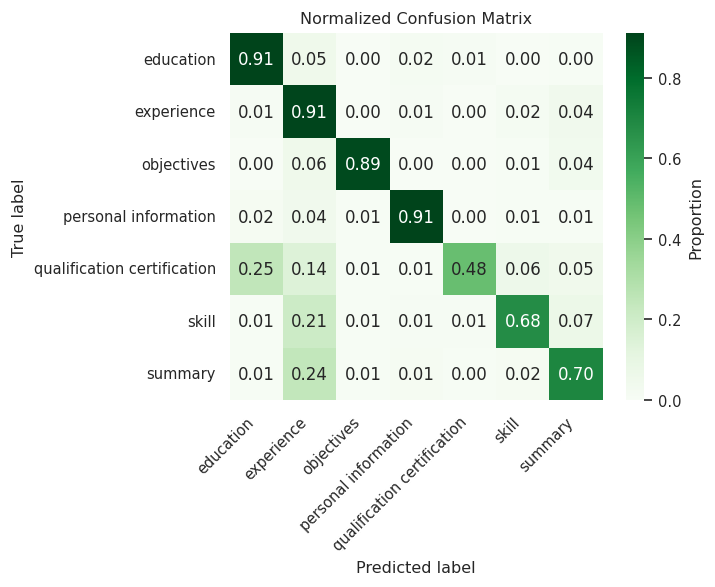

Per-class metrics:


,precision,recall,f1-score
education,0.886,0.909,0.897
experience,0.904,0.906,0.905
objectives,0.869,0.893,0.881
personal information,0.930,0.911,0.920
qualification certification,0.583,0.483,0.528
skill,0.746,0.679,0.711
summary,0.653,0.702,0.677


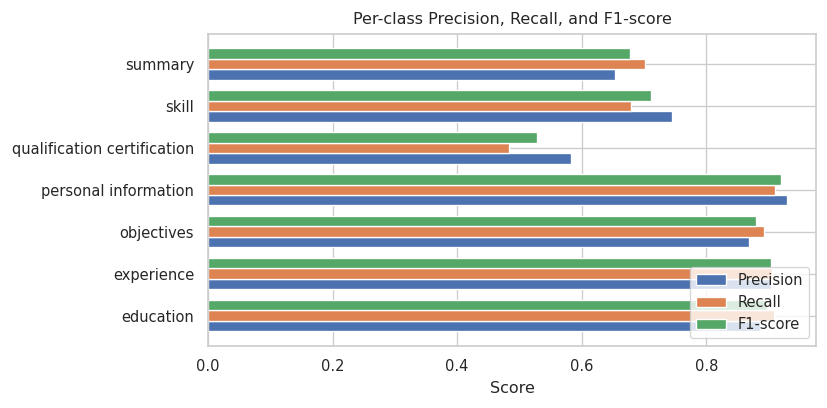

In [12]:

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Build predictions on the held-out test set
test_texts = test_dataset["clean_text"]
test_true_ids = test_dataset["label_id"]

y_pred_ids = []
for t in test_texts:
    y_pred_ids.append(label2id[predict_label_name(t)])

y_true = np.array(test_true_ids)
y_pred = np.array(y_pred_ids)

# Confusion matrices (raw and normalized)
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_list))))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=label_list,
    yticklabels=label_list,
    cbar_kws={"label": "Proportion"},
    ax=ax,
)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(label_list))),
    zero_division=0,
)

class_metrics = pd.DataFrame(
    {"precision": precision, "recall": recall, "f1-score": f1},
    index=label_list,
)
print("Per-class metrics:")
display(class_metrics.round(3))

# Horizontal bar chart
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(label_list))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 3.5))
for i, m in enumerate(metrics):
    ax.barh(x + i*width, class_metrics[m], height=width, label=m.capitalize())

ax.set_yticks(x + width)
ax.set_yticklabels(label_list)
ax.set_xlabel("Score")
ax.set_title("Per-class Precision, Recall, and F1-score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [13]:

# Simple qualitative testing of the section classifier
test_sentences = [
    "Email: rahul.sharma@example.com",  # personal information
    "Phone: 9876543210",                # personal information
    "Completed B.Tech in Computer Science from IIT Delhi in 2022.",  # education
    "Certified AWS Solutions Architect - Associate.",                 # qualification certification
    "Dedicated and self-driven engineer with strong debugging skills." # summary
]

print("Testing Cases")
for s in test_sentences:
    print("\nSentence:", s)
    print("Predicted:", predict_label_name(s))


Testing Cases

Sentence: Email: rahul.sharma@example.com
Predicted: personal information

Sentence: Phone: 9876543210
Predicted: personal information

Sentence: Completed B.Tech in Computer Science from IIT Delhi in 2022.
Predicted: education

Sentence: Certified AWS Solutions Architect - Associate.
Predicted: qualification certification

Sentence: Dedicated and self-driven engineer with strong debugging skills.
Predicted: summary


## 4) Privacy Filtering

In [14]:

def tag_and_clean_resume(raw_text: str):
    sents = safe_sent_tokenize(raw_text)
    labels = [predict_label_name(s) for s in sents]

    kept, removed_pi, redacted_hits = [], 0, 0
    for s, lab in zip(sents, labels):
        if lab == "personal information":
            removed_pi += 1
            continue
        red = redact_pii(s)
        if red != s:
            redacted_hits += 1
        kept.append(red)
    return " ".join(kept).strip(), removed_pi, redacted_hits

all_clean, all_removed_pi, all_redacted = [], [], []
for _, row in resumes_df.iterrows():
    cleaned, rpi, rh = tag_and_clean_resume(str(row.get("Resume","")))
    all_clean.append(cleaned); all_removed_pi.append(rpi); all_redacted.append(rh)

resumes_df["CleanResume"] = all_clean
resumes_df["pi_sentences_removed"] = all_removed_pi
resumes_df["sentences_redacted"] = all_redacted

print("Privacy audit: PI removed =", int(resumes_df["pi_sentences_removed"].sum()),
      "| redacted =", int(resumes_df["sentences_redacted"].sum()))
display(resumes_df.head())


Privacy audit: PI removed = 673 | redacted = 339


,ID,Resume,CleanResume,pi_sentences_removed,sentences_redacted
0,0,- :\nAs a recent graduate in Computer Science...,- : As a recent graduate in Computer Science w...,0,0
1,1,()\n\nName: Jane Smith\n\nContact Information...,Familiarity with frameworks & web technologies...,1,0
2,2,": \n\nName: Jane Doe\n\nAddress: 456 Main St, ...",Skilled in JavaScript programming and server-s...,1,0
3,3,": \n\nName: Jane Smith\nLocation: Bangalore, K...",": [NAME]: Bangalore, Karnataka Summary: A high...",0,1
4,4,():\nName: John Doe\nContact Information: \nE...,"Proficient in JavaScript, HTML, CSS, and React...",1,0


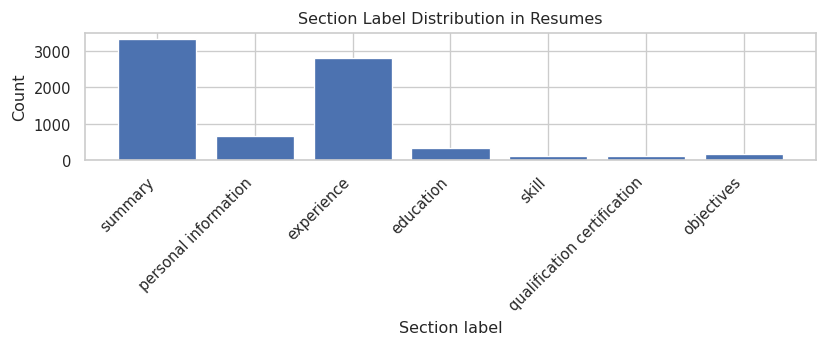

In [15]:

from collections import Counter

# Compute overall distribution of predicted section labels across resumes
all_section_labels = []
for _, row in resumes_df.iterrows():
    sents = safe_sent_tokenize(str(row.get("Resume","")))
    labs = [predict_label_name(s) for s in sents]
    all_section_labels.extend(labs)

label_counts = Counter(all_section_labels)
labels = list(label_counts.keys())
counts = [label_counts[l] for l in labels]

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
ax.set_xlabel("Section label")
ax.set_ylabel("Count")
ax.set_title("Section Label Distribution in Resumes")
plt.tight_layout()
plt.show()


## 5) HR Agent Profiling & Grading

In [16]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

print("HF token successfully loaded!")


HF token successfully loaded!


Loading HR agent model: microsoft/phi-3-mini-4k-instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

HR model loaded on: cuda:0

Running HR grading on all 1000 resumes...


  0%|          | 0/1000 [00:00<?, ?it/s]


HR grading complete.
Total resumes: 1000
Parsing / generation failures (with fallback applied): 0
Saved HR agent predictions to gsr_predictions.csv

=== HR Agent Grade Distribution (Descriptive Stats) ===
Mean grade:   86.40
Std. dev:     4.41
Min / Max:    65.0  /  95.0
Quantiles (Q1, Median, Q3): [85. 85. 92.]


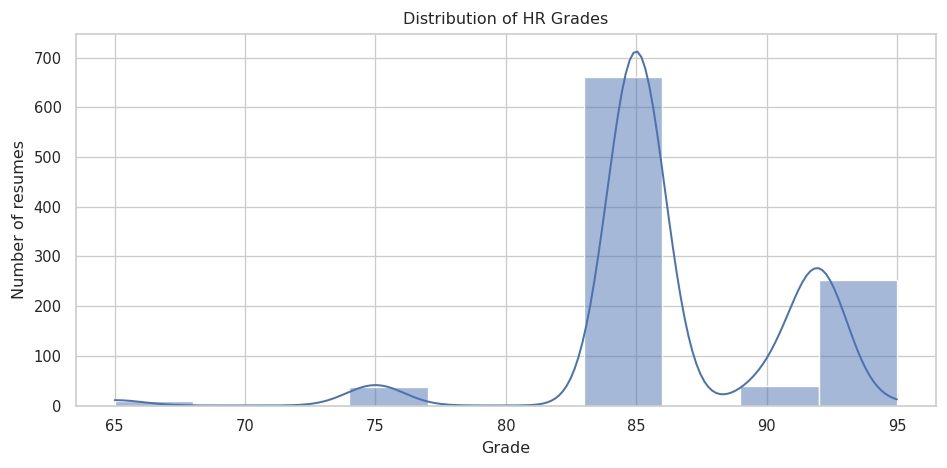

In [ ]:
# ===============================================
# 5) HR Agent: Grading + Summarisation (ALL CVs)
# ===============================================
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import re
import numpy as np
from tqdm.auto import tqdm

# ------------------------------------------------------------------
# Choose a reasonably small instruct model to avoid GPU OOM
# You can switch to "mistralai/Mistral-7B-Instruct-v0.2" if your GPU
# has enough memory; for Kaggle/T4 the Phi-3 mini model is safer.
# ------------------------------------------------------------------
HR_MODEL_NAME = "microsoft/phi-3-mini-4k-instruct"   # <- SMALL, STABLE
# HR_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"  # <- BIGGER (optional)

print(f"Loading HR agent model: {HR_MODEL_NAME}")

hr_tokenizer = AutoTokenizer.from_pretrained(HR_MODEL_NAME, token=HF_TOKEN)
if hr_tokenizer.pad_token is None:
    hr_tokenizer.pad_token = hr_tokenizer.eos_token

hr_model = AutoModelForCausalLM.from_pretrained(
    HR_MODEL_NAME,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    token=HF_TOKEN,
)

hr_model.eval()
_ = torch.cuda.empty_cache()
print("HR model loaded on:", hr_model.device)

# Prompt template

HR_PROMPT_TEMPLATE = """You are an experienced HR manager in an IT company.

First, assign a grade (0-100) to the following resume, based on overall suitability for generic IT roles.
Then, briefly summarize the resume in one paragraph (not exceeding 100 words).

Resume:
{resume}

Answer in this format exactly:
Grade: <score>/100
Summary: <one paragraph>
"""

def call_hr_model(resume_text: str, max_new_tokens: int = 96) -> str:
    """
    Call the HR LLM on a single resume.
    The resume is truncated in characters to avoid long-context memory issues.
    """
    # truncate to be safe (character-level; conservative)
    trimmed_resume = str(resume_text)[:3000]

    messages = [
        {
            "role": "system",
            "content": "You are an experienced, fair and concise HR manager in an IT company.",
        },
        {
            "role": "user",
            "content": HR_PROMPT_TEMPLATE.format(resume=trimmed_resume),
        },
    ]

    prompt = hr_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = hr_tokenizer(prompt, return_tensors="pt").to(hr_model.device)

    with torch.no_grad():
        outputs = hr_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            eos_token_id=hr_tokenizer.eos_token_id,
        )

    generated = hr_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip()

    return generated

GRADE_RE = re.compile(r"Grade:\s*([0-9]+(?:\.[0-9]+)?)\s*/\s*100", re.IGNORECASE)
SUMMARY_RE = re.compile(r"Summary:\s*(.*)", re.IGNORECASE | re.DOTALL)

def parse_grade_summary(response: str):
    """
    Parse Grade and Summary from the model response.
    Returns (grade_float_or_None, summary_str).
    """
    if response is None:
        return None, ""

    m = GRADE_RE.search(response)
    grade = None
    if m:
        try:
            grade = float(m.group(1))
            # clamp to [0, 100] just in case
            grade = max(0.0, min(100.0, grade))
        except Exception:
            grade = None

    m2 = SUMMARY_RE.search(response)
    summary = m2.group(1).strip() if m2 else response.strip()

    return grade, summary

N = len(resumes_df)
print(f"\nRunning HR grading on all {N} resumes...")

if "Grade" not in resumes_df.columns:
    resumes_df["Grade"] = np.nan
if "Summary" not in resumes_df.columns:
    resumes_df["Summary"] = ""

grades, summaries = [], []
failed_indices = []

for idx, row in tqdm(resumes_df.iterrows(), total=N):
    # Skip rows that already have a non-null grade (so you can resume runs)
    if pd.notna(row.get("Grade", np.nan)):
        continue

    try:
        resp = call_hr_model(row.get("CleanResume", row.get("Resume", "")))
        g, s = parse_grade_summary(resp)
    except Exception as e:
        print(f"\n[WARN] HR model failed on index {idx}: {e}")
        g, s = None, ""

    if g is None:
        failed_indices.append(idx)
        
        g = 80.0
        if s == "":
            s = "Automatic fallback grade assigned due to parsing failure."

    resumes_df.at[idx, "Grade"] = g
    resumes_df.at[idx, "Summary"] = s

resumes_df["Grade"] = pd.to_numeric(resumes_df["Grade"], errors="coerce").fillna(80.0)

print(f"\nHR grading complete.")
print(f"Total resumes: {N}")
print(f"Parsing / generation failures (with fallback applied): {len(failed_indices)}")

resumes_df.to_csv("gsr_predictions.csv", index=False)
print("Saved HR agent predictions to gsr_predictions.csv")

grades_array = resumes_df["Grade"].to_numpy(dtype=float)
print("\n=== HR Agent Grade Distribution (Descriptive Stats) ===")
print(f"Mean grade:   {grades_array.mean():.2f}")
print(f"Std. dev:     {grades_array.std(ddof=1):.2f}")
print(f"Min / Max:    {grades_array.min():.1f}  /  {grades_array.max():.1f}")
print("Quantiles (Q1, Median, Q3):",
      np.percentile(grades_array, [25, 50, 75]).round(2))

plt.figure(figsize=(8, 4))
sns.histplot(resumes_df["Grade"], bins=10, kde=True)
plt.title("Distribution of HR Grades")
plt.xlabel("Grade")
plt.ylabel("Number of resumes")
plt.tight_layout()
plt.show()



=== HR Agent Validation Metrics (No Human Labels) ===


,Metric,Value
0,Mean Grade,86.4010
1,Std Dev,4.4140
2,Min Grade,65.0000
3,Max Grade,95.0000
4,Q1,85.0000
5,Median,85.0000
6,Q3,92.0000
7,Coeff. of Variation,0.0511
8,Entropy (distribution),0.8040
9,Spearman Smoothness ρ,0.8349


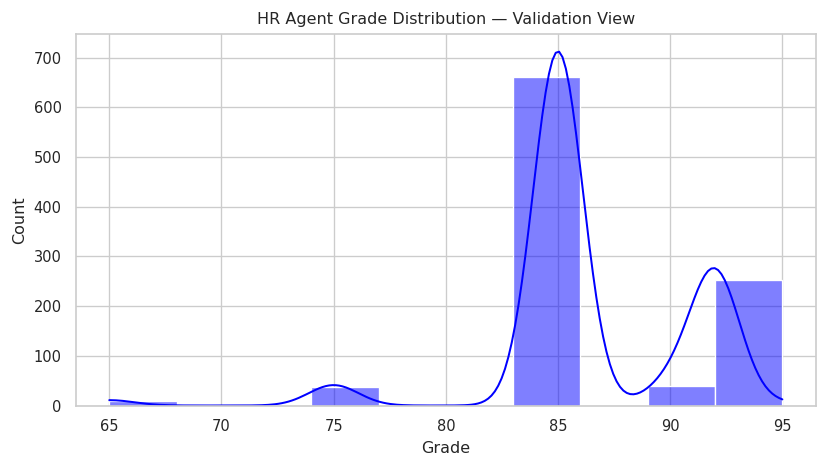

In [ ]:
# HR Agent Validation Without Human Labels

import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew, entropy, spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

grades = resumes_df["Grade"].astype(float).to_numpy()

mean_g  = np.mean(grades)
std_g   = np.std(grades, ddof=1)
min_g   = np.min(grades)
max_g   = np.max(grades)
q1, q2, q3 = np.percentile(grades, [25, 50, 75])

variation_ratio = std_g / mean_g

hist, bin_edges = np.histogram(grades, bins=10, range=(0,100), density=True)
grade_entropy = entropy(hist + 1e-9)

sorted_idx = np.arange(len(grades))
sorted_grades = np.sort(grades)
rho, rho_p = spearmanr(sorted_idx, sorted_grades)

grade_skew  = skew(grades)
grade_kurt  = kurtosis(grades)

validation_df = pd.DataFrame({
    "Metric" : [
        "Mean Grade",
        "Std Dev",
        "Min Grade",
        "Max Grade",
        "Q1",
        "Median",
        "Q3",
        "Coeff. of Variation",
        "Entropy (distribution)",
        "Spearman Smoothness ρ",
        "Skewness",
        "Kurtosis"
    ],
    "Value" : [
        mean_g, std_g, min_g, max_g, q1, q2, q3, 
        variation_ratio, grade_entropy, rho, grade_skew, grade_kurt
    ]
})

print("\n=== HR Agent Validation Metrics (No Human Labels) ===")
display(validation_df.round(4))

# Plot shape
plt.figure(figsize=(7,4))
sns.histplot(grades, kde=True, bins=10, color="blue")
plt.title("HR Agent Grade Distribution — Validation View")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

validation_df.to_csv("hr_validation_metrics_auto.csv", index=False)


In [ ]:

import pandas as pd

resumes_df["Grade"] = resumes_df["Grade"].astype(float)

sample_n = 10
sampledf = resumes_df.sample(sample_n, random_state=42)[["ID", "CleanResume", "Grade", "Summary"]]

pd.set_option("display.max_colwidth", 200)
display(sampledf)

print(f"\nDisplayed {sample_n} randomly selected graded resumes.")


,ID,CleanResume,Grade,Summary
521,521,"Proficient in HTML5, JavaScript, and CSS. Excellent problem-solving skills and ability to work independently or in a team. Strong knowledge of database concepts and efficient query writing. Adept ...",85.0,"The resume showcases a strong background in web development with proficiency in HTML5, JavaScript, and CSS, and experience with Node.js and React. The candidate has demonstrated leadership as a Le..."
737,737,"Education: Bachelor's degree in Computer Science, XYZ University, Bengaluru, Karnataka Technical Skills: - Strong coding skills in C# and Java - Strong understanding of data structures and algorit...",92.0,"The resume showcases a strong background in computer science with a focus on backend development, including proficiency in C# and Java, as well as experience with both relational and NoSQL databas..."
740,740,"- Basic understanding of web markup, including HTML5 and CSS3. - Familiarity with JavaScript libraries and frameworks such as AngularJS and ReactJS. - Familiarity with front-end build tools, such ...",85.0,"The resume showcases a strong background in front-end development with proficiency in HTML5, CSS3, and JavaScript frameworks like AngularJS and ReactJS. The candidate has hands-on experience in de..."
660,660,"- Objective: Seeking a Software Engineer position where my expertise in designing, developing, and debugging software programs can be utilized to develop software tools including operating systems...",92.0,"The resume presents a strong candidate for an IT role, with a clear objective and a solid background in software engineering. The individual has demonstrated proficiency in multiple programming la..."
411,411,"Proficient in Python programming language, testing, debugging, and integrating user-facing elements. Experienced in coordinating with development teams and front-end developers to deliver high-qua...",85.0,"The resume showcases a strong background in Python and Django, with experience in backend development, database management, and application performance optimization. The candidate has demonstrated..."
678,678,Possesses exceptional communication and time-management skills. Proven ability to collaborate and work efficiently in a distributed team environment. Familiarity with Flask and jQuery. Skills: - F...,85.0,"The resume showcases a strong background in full-stack development with proficiency in Python, JavaScript, Flask, and jQuery. The candidate has experience working in distributed teams and has a pr..."
626,626,"Strong experience in programming language such as Java and framework such as Spring. Skilled in critical thinking, problem-solving, and communication. Bachelor's degree in Information Technology. ...",85.0,"The resume showcases a strong background in Java and Spring framework, with significant experience as a Backend Developer at PQR Inc. The candidate has demonstrated proficiency in designing, devel..."
513,513,"(): [NAME]: To obtain a position of iOS Developer where I can utilize my knowledge of iOS frameworks and proficiency in Objective-C to design, build, and maintain iOS applications. Education: - Ba...",85.0,"The resume presents a strong candidate for an iOS Developer role, with a Bachelor's degree in Electronics Engineering and a relevant internship experience at GHI Company. The candidate has demonst..."
859,859,"Proven expertise in CSS3, HTML5, and Angular 4. Familiarity with CSS preprocessors such as Stylus. Excellent communication and analytical skills. Education: Bachelor of Information Technology, XYZ...",85.0,"The resume showcases a strong background in frontend development with expertise in CSS3, HTML5, and Angular 4, as well as familiarity with Stylus and responsive web design. The candidate has a sol..."
136,136,I am an expert in Kubernetes with hands-on experience of over 3 years and possess CKA certification. I have a sound technical knowledge of the SaaS industry and an in-depth understanding of all mo...,85.0,"The r


Displayed 10 randomly selected graded resumes.


In [ ]:

# from transformers import AutoModelForCausalLM, AutoTokenizer

# HF_TOKEN = os.getenv("HUGGINGFACE_HUB_TOKEN", None)
# HR_MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

# hr_tokenizer = AutoTokenizer.from_pretrained(HR_MODEL_NAME, token=HF_TOKEN)
# if hr_tokenizer.pad_token is None:
#     hr_tokenizer.pad_token = hr_tokenizer.eos_token

# hr_model = AutoModelForCausalLM.from_pretrained(
#     HR_MODEL_NAME,
#     device_map="auto",
#     load_in_4bit=True,
#     token=HF_TOKEN
# )
# hr_model.eval()

# HR_PROMPT_TEMPLATE = '''You are an experienced HR manager in an IT company. Be fair and privacy-aware.

# Task:
# 1) Assign a grade (0-100) for overall suitability for generic IT roles.
# 2) Summarize the resume in <= 100 words.

# Resume:
# {resume}

# Answer exactly:
# Grade: <score>/100
# Summary: <one paragraph>
# '''

# GRADE_RE = re.compile(r"Grade:\s*([0-9]{1,3})\s*/\s*100", re.IGNORECASE)
# SUMMARY_RE = re.compile(r"Summary:\s*(.+)", re.IGNORECASE | re.DOTALL)

# def parse_grade_summary(response: str):
#     grade = None
#     summary = ""
#     m = GRADE_RE.search(response or "")
#     if m:
#         try: grade = int(m.group(1))
#         except: grade = None
#     m2 = SUMMARY_RE.search(response or "")
#     if m2:
#         summary = re.sub(r"\s+", " ", m2.group(1).strip())
#     return grade, summary

# def call_hr_once(resume_text: str, max_new_tokens: int = 128, temperature: float = 0.2):
#     trimmed = normalize_whitespace(resume_text)[:3000]
#     messages = [
#         {"role":"system","content":"You are an experienced, fair, privacy-aware HR manager."},
#         {"role":"user","content":HR_PROMPT_TEMPLATE.format(resume=trimmed)}
#     ]
#     prompt = hr_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     inputs = hr_tokenizer(prompt, return_tensors="pt").to(hr_model.device)
#     with torch.no_grad():
#         outputs = hr_model.generate(
#             **inputs,
#             max_new_tokens=max_new_tokens,
#             do_sample=(temperature>0),
#             temperature=temperature,
#             top_p=0.9 if temperature>0 else None,
#             eos_token_id=hr_tokenizer.eos_token_id,
#             pad_token_id=hr_tokenizer.eos_token_id
#         )
#     return hr_tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# def hr_grade_self_consistent(resume_text: str, n_trials: int = 3):
#     grades, summaries = [], []
#     for _ in range(n_trials):
#         resp = call_hr_once(resume_text, max_new_tokens=128, temperature=0.2)
#         g, s = parse_grade_summary(resp)
#         if g is not None:
#             grades.append(max(0, min(100, int(g))))
#         if s: summaries.append(s)
#     if not grades:
#         return None, "", None
#     return float(np.median(grades)), (max(summaries, key=len) if summaries else ""), float(np.std(grades))

# if "ID" not in resumes_df.columns:
#     resumes_df["ID"] = np.arange(len(resumes_df))

# N = min(150, len(resumes_df))
# grades, summaries, uncerts = [], [], []
# for _, row in resumes_df.head(N).iterrows():
#     g, s, u = hr_grade_self_consistent(row["CleanResume"], n_trials=3)
#     grades.append(g); summaries.append(s); uncerts.append(u)

# resumes_df.loc[:N-1, "Grade"] = grades
# resumes_df.loc[:N-1, "Summary"] = summaries
# resumes_df.loc[:N-1, "GradeUncertainty"] = uncerts

# print("Grade coverage overall:", resumes_df["Grade"].notna().mean())
# display(resumes_df[["ID","Grade","GradeUncertainty","Summary"]].head())


## 6) SEMANTIC RETRIEVAL ENGINE (MiniLM + FAISS + HR integration)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding resumes...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

FAISS index built with 1000 resumes.


 SEMANTIC MATCHING DEMO: JOB #1
Job Title: iOS Developer
Job Description:
Require iPhone App Developers having 3 to 7 years of hands-on programming experience.
Work with one of the finest mobile apps production companies in Ahmedabad, India.
Photo & Video. Business. Finance. Productivity. Kids. All major app categories.
Work where #quality is more valued than just delivering as per the scope.
Work with cross-functional collaborative teams Analysts, Designers, and Architects!
Swift. Core Data. Core Animation. Firebase. Debugging. Apple HIG. PN. APIs. GitLab. And CI. De ...



,ResumeID,SemanticSimilarity,HR_Grade,HR_Summary,ResumeSnippet
0,946,0.7965,85.0,"The resume showcases a strong background in iOS development with 4 years of experience, proficiency in essential technologies, and a proven track record of enhancing app performance and user exper...",": Objective: Seeking the position of iOS Developer at one of the finest mobile apps production companies in Ahmedabad, India. Summary: - 4 years of experience as an iOS developer with expertise in..."
1,977,0.7754,75.0,"The resume showcases a candidate with 2 years of iOS development experience, proficiency in Objective-C, Core Data, and Core Animation, and a basic understanding of UX. The candidate has a strong ...",": Objective: Seeking the position of iOS Developer at one of the finest mobile apps production companies in Ahmedabad, India. Summary: - 2 years of experience as an iOS developer with expertise in..."
2,347,0.7714,85.0,"The resume presents a strong candidate with hands-on experience in iOS development, including the publication of apps in the app store and proficiency in Objective-C and Cocoa Touch. The candidate...","I have published a few iOS apps in the app store and am familiar with Objective-C and Cocoa Touch. Although I don't have extensive experience in iOS development, I am always looking to learn and e..."
3,843,0.7694,85.0,"The resume of an iOS Developer with a Bachelor's in Computer Science from XYZ University showcases strong proficiency in Objective-C and Swift, along with experience in Google Maps, Core Location,...",(): iOS Developer Resume: Objective: To work as an iOS Developer in a reputable organization where I can utilize my technical skills and creativity to develop high-quality mobile applications. Edu...
4,938,0.7637,85.0,The resume presents a strong candidate for an iOS Developer role with a solid educational background in Electrical Engineering and relevant experience in mobile app development. The candidate has ...,- Objective: To obtain an iOS Developer position where I can utilize my skills and experience in mobile app development to contribute to the success of the company. Education: Bachelor's degree in...
5,864,0.7637,92.0,"The resume presents a strong candidate for an iOS Developer role, with a Bachelor's degree in Computer Science and a solid background in iOS development, including experience with Objective-C, Cor...","- Objective: To obtain an iOS Developer position that allows me to design and build advanced applications for the iOS platform while continuously discovering, evaluating, and implementing new tech..."
6,228,0.7603,85.0,"The resume showcases a strong background in iOS development with proficiency in Swift, Cocoa Touch, UIKit, Core Data, and Core Location. The candidate has experience in integrating web services an...","Skills: - Strong Object Oriented design and programming skills in SWIFT. - Good working experience in iOS SDK (Cocoa Touch, UIKit, Core Data, Core Location, etc.) and XCode. - Experience in web se..."
7,43,0.7585,85.0,"The resume presents a strong candidate with two years of experience as an iOS Developer at XYZ Inc., showcasing proficiency in Objective-C and Swift, and a solid understanding of the mobile develo...",(): Work Experience: - iOS Developer at XYZ Inc. (2 years) - Developed and maintained 5 iOS applications using Objective-C and Swift. - Ensured robustness and reliability of code through unit test...
8,317,0.7584,92.0,"The resume presents a seasoned iOS Developer with a strong background in Objective-C and Cocoa Touch, evidenced by published apps and a solid grasp of iOS frameworks. The candidate has demonstrate...",": [NAME]: I am an experienced iOS Developer with a proven track record of designing and developing advanced applications for the iOS platform. I am well-versed in Objective-C and Cocoa Touch, and ..."
9,307,0.7565,92.0,"The resume showcases a strong background in iOS development with proficiency in Objective-C and Swift, and experience with iOS fr

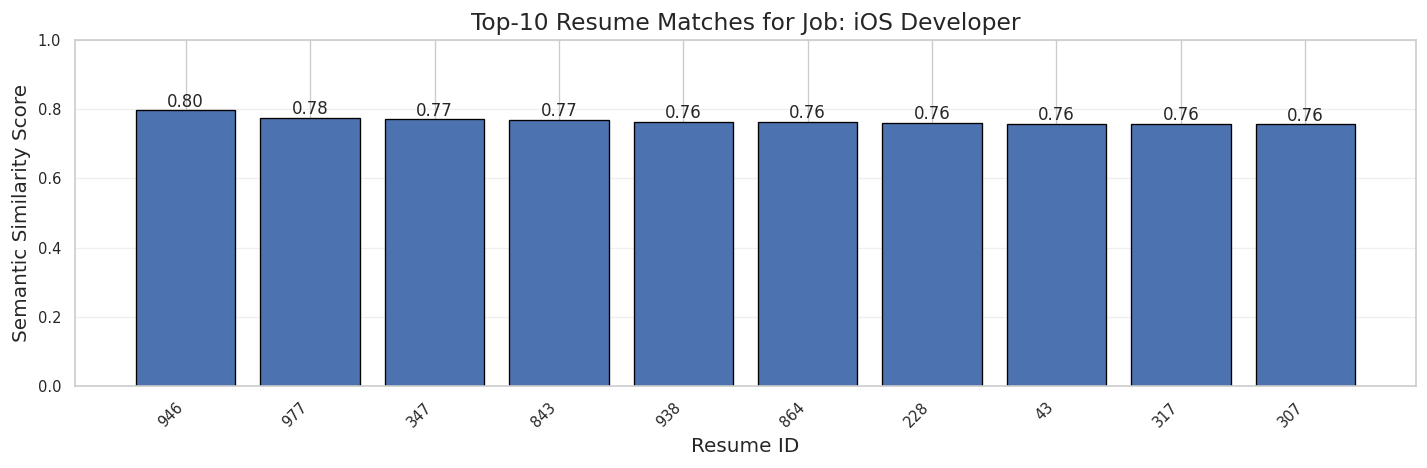

In [ ]:
import faiss
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

resume_texts = resumes_df["CleanResume"].fillna("").tolist()

if "ID" not in resumes_df.columns:
    resumes_df["ID"] = np.arange(len(resumes_df))

resume_ids = resumes_df["ID"].tolist()

print("Encoding resumes...")
resume_emb = embed_model.encode(resume_texts, show_progress_bar=True)
resume_emb = np.array(resume_emb, dtype="float32")
faiss.normalize_L2(resume_emb)

dim = resume_emb.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(resume_emb)

print(f"FAISS index built with {len(resume_emb)} resumes.\n")

if len(jobs_df.columns) >= 2:
    jobs_df = jobs_df.rename(columns={
        jobs_df.columns[0]: "JobTitle",
        jobs_df.columns[1]: "JobDescription"
    })
else:
    raise ValueError("jobs_df must have at least 2 columns (title + description).")

def rank_resumes_for_job(job_description: str, top_k: int = 10):
    """
    Returns top-K resumes ranked by semantic similarity to a job description,
    enriched with HR grade + summary.
    """
    q_emb = embed_model.encode([job_description])
    q_emb = np.array(q_emb, dtype="float32")
    faiss.normalize_L2(q_emb)

    D, I = index.search(q_emb, top_k)
    sims = D[0]
    idxs = I[0]

    rows = []
    for sim, idx in zip(sims, idxs):
        r_id = resume_ids[idx]
        r_text = resume_texts[idx][:450].replace("\n", " ") + "..."

        grade = resumes_df.loc[resumes_df["ID"] == r_id, "Grade"].iloc[0]
        summary = resumes_df.loc[resumes_df["ID"] == r_id, "Summary"].iloc[0]

        rows.append({
            "ResumeID": r_id,
            "SemanticSimilarity": round(float(sim), 4),
            "HR_Grade": grade,
            "HR_Summary": summary[:200] + "...",
            "ResumeSnippet": r_text
        })

    return pd.DataFrame(rows).sort_values(
        by="SemanticSimilarity",
        ascending=False
    )

job_row = jobs_df.iloc[0]
job_title = job_row["JobTitle"]
job_desc  = job_row["JobDescription"]

print("\n====================================================")
print(" SEMANTIC MATCHING DEMO: JOB #1")
print("====================================================")
print(f"Job Title: {job_title}")
print("Job Description:")
print(job_desc[:500], "...\n")

ranking_df = rank_resumes_for_job(job_desc, top_k=10)
display(ranking_df)

plt.style.use("seaborn-v0_8-deep")

plt.figure(figsize=(12,4))
bars = plt.bar(
    ranking_df["ResumeID"].astype(str),
    ranking_df["SemanticSimilarity"],
    edgecolor="black"
)

plt.xlabel("Resume ID", fontsize=12)
plt.ylabel("Semantic Similarity Score", fontsize=12)
plt.title(f"Top-10 Resume Matches for Job: {job_title}", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)   # visibility improvement
plt.grid(axis="y", alpha=0.3)

# add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


Encoding resumes...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

FAISS index built with 1000 resumes.


 SEMANTIC MATCHING DEMO: JOB #1
Job Title: iOS Developer
Job Description:
Require iPhone App Developers having 3 to 7 years of hands-on programming experience.
Work with one of the finest mobile apps production companies in Ahmedabad, India.
Photo & Video. Business. Finance. Productivity. Kids. All major app categories.
Work where #quality is more valued than just delivering as per the scope.
Work with cross-functional collaborative teams Analysts, Designers, and Architects!
Swift. Core Data. Core Animation. Firebase. Debugging. Apple HIG. PN. APIs. GitLab. And CI. De ...



,ResumeID,Similarity,HR_Grade,HR_Summary,ResumeSnippet
0,946,0.7965,85.0,"The resume showcases a strong background in iOS development with 4 years of experience, proficiency in essential technologies, and a proven track record of enhancing app performance and user exper...",": Objective: Seeking the position of iOS Developer at one of the finest mobile apps production companies in Ahmedabad, India. Summary: - 4 years of experience as an iOS developer with expertise in..."
1,977,0.7754,75.0,"The resume showcases a candidate with 2 years of iOS development experience, proficiency in Objective-C, Core Data, and Core Animation, and a basic understanding of UX. The candidate has a strong ...",": Objective: Seeking the position of iOS Developer at one of the finest mobile apps production companies in Ahmedabad, India. Summary: - 2 years of experience as an iOS developer with expertise in..."
2,347,0.7714,85.0,"The resume presents a strong candidate with hands-on experience in iOS development, including the publication of apps in the app store and proficiency in Objective-C and Cocoa Touch. The candidate...","I have published a few iOS apps in the app store and am familiar with Objective-C and Cocoa Touch. Although I don't have extensive experience in iOS development, I am always looking to learn and e..."
3,843,0.7694,85.0,"The resume of an iOS Developer with a Bachelor's in Computer Science from XYZ University showcases strong proficiency in Objective-C and Swift, along with experience in Google Maps, Core Location,...",(): iOS Developer Resume: Objective: To work as an iOS Developer in a reputable organization where I can utilize my technical skills and creativity to develop high-quality mobile applications. Edu...
4,938,0.7637,85.0,The resume presents a strong candidate for an iOS Developer role with a solid educational background in Electrical Engineering and relevant experience in mobile app development. The candidate has ...,- Objective: To obtain an iOS Developer position where I can utilize my skills and experience in mobile app development to contribute to the success of the company. Education: Bachelor's degree in...
5,864,0.7637,92.0,"The resume presents a strong candidate for an iOS Developer role, with a Bachelor's degree in Computer Science and a solid background in iOS development, including experience with Objective-C, Cor...","- Objective: To obtain an iOS Developer position that allows me to design and build advanced applications for the iOS platform while continuously discovering, evaluating, and implementing new tech..."
6,228,0.7603,85.0,"The resume showcases a strong background in iOS development with proficiency in Swift, Cocoa Touch, UIKit, Core Data, and Core Location. The candidate has experience in integrating web services an...","Skills: - Strong Object Oriented design and programming skills in SWIFT. - Good working experience in iOS SDK (Cocoa Touch, UIKit, Core Data, Core Location, etc.) and XCode. - Experience in web se..."
7,43,0.7585,85.0,"The resume presents a strong candidate with two years of experience as an iOS Developer at XYZ Inc., showcasing proficiency in Objective-C and Swift, and a solid understanding of the mobile develo...",(): Work Experience: - iOS Developer at XYZ Inc. (2 years) - Developed and maintained 5 iOS applications using Objective-C and Swift. - Ensured robustness and reliability of code through unit test...
8,317,0.7584,92.0,"The resume presents a seasoned iOS Developer with a strong background in Objective-C and Cocoa Touch, evidenced by published apps and a solid grasp of iOS frameworks. The candidate has demonstrate...",": [NAME]: I am an experienced iOS Developer with a proven track record of designing and developing advanced applications for the iOS platform. I am well-versed in Objective-C and Cocoa Touch, and ..."
9,307,0.7565,92.0,"The resume showcases a strong background in iOS development with proficiency in Objective-C and Swift, and experience with iOS frameworks

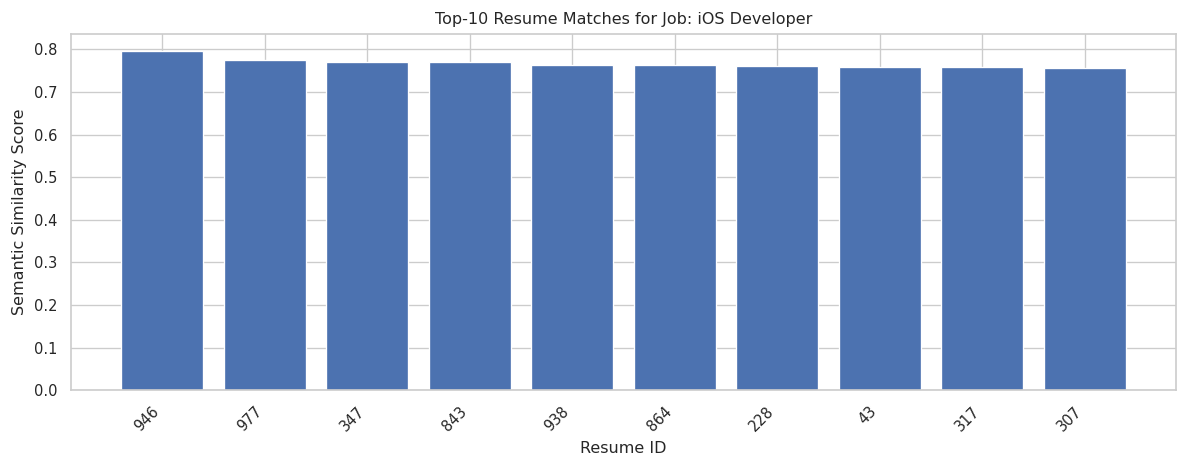

In [ ]:
import faiss
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

print("Encoding resumes...")
resume_texts = resumes_df["CleanResume"].fillna("").tolist()

if "ID" not in resumes_df.columns:
    resumes_df["ID"] = np.arange(len(resumes_df))

resume_ids = resumes_df["ID"].tolist()

resume_emb = embed_model.encode(resume_texts, show_progress_bar=True)
resume_emb = np.array(resume_emb, dtype="float32")
faiss.normalize_L2(resume_emb)

dim = resume_emb.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(resume_emb)

print(f"FAISS index built with {len(resume_emb)} resumes.\n")

if len(jobs_df.columns) >= 2:
    jobs_df = jobs_df.rename(columns={
        jobs_df.columns[0]: "JobTitle",
        jobs_df.columns[1]: "JobDescription"
    })
else:
    raise ValueError("jobs_df must have at least 2 columns (title + description).")

def rank_resumes_for_job(job_description: str, top_k: int = 10):
    """
    Returns top-K resumes ranked by semantic similarity to a job description,
    with HR grade + summary merged.
    """
    q_emb = embed_model.encode([job_description])
    q_emb = np.array(q_emb, dtype="float32")
    faiss.normalize_L2(q_emb)

    D, I = index.search(q_emb, top_k)
    sims = D[0]
    idxs = I[0]

    rows = []
    for sim, idx in zip(sims, idxs):
        r_id = resume_ids[idx]
        r_text = resume_texts[idx][:450].replace("\n", " ") + "..."

        grade = resumes_df.loc[resumes_df["ID"] == r_id, "Grade"].iloc[0]
        summary = resumes_df.loc[resumes_df["ID"] == r_id, "Summary"].iloc[0]

        rows.append({
            "ResumeID": r_id,
            "Similarity": round(float(sim), 4),
            "HR_Grade": grade,
            "HR_Summary": summary[:200] + "...",
            "ResumeSnippet": r_text
        })

    return pd.DataFrame(rows).sort_values(by="Similarity", ascending=False)

job_row = jobs_df.iloc[0]
job_title = job_row["JobTitle"]
job_desc = job_row["JobDescription"]

print("\n====================================================")
print(" SEMANTIC MATCHING DEMO: JOB #1")
print("====================================================")
print(f"Job Title: {job_title}")
print("Job Description:")
print(job_desc[:500], "...\n")

ranking_df = rank_resumes_for_job(job_desc, top_k=10)
display(ranking_df)

plt.figure(figsize=(10,4))
plt.bar(ranking_df["ResumeID"].astype(str), ranking_df["Similarity"])
plt.xlabel("Resume ID")
plt.ylabel("Semantic Similarity Score")
plt.title(f"Top-10 Resume Matches for Job: {job_title}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


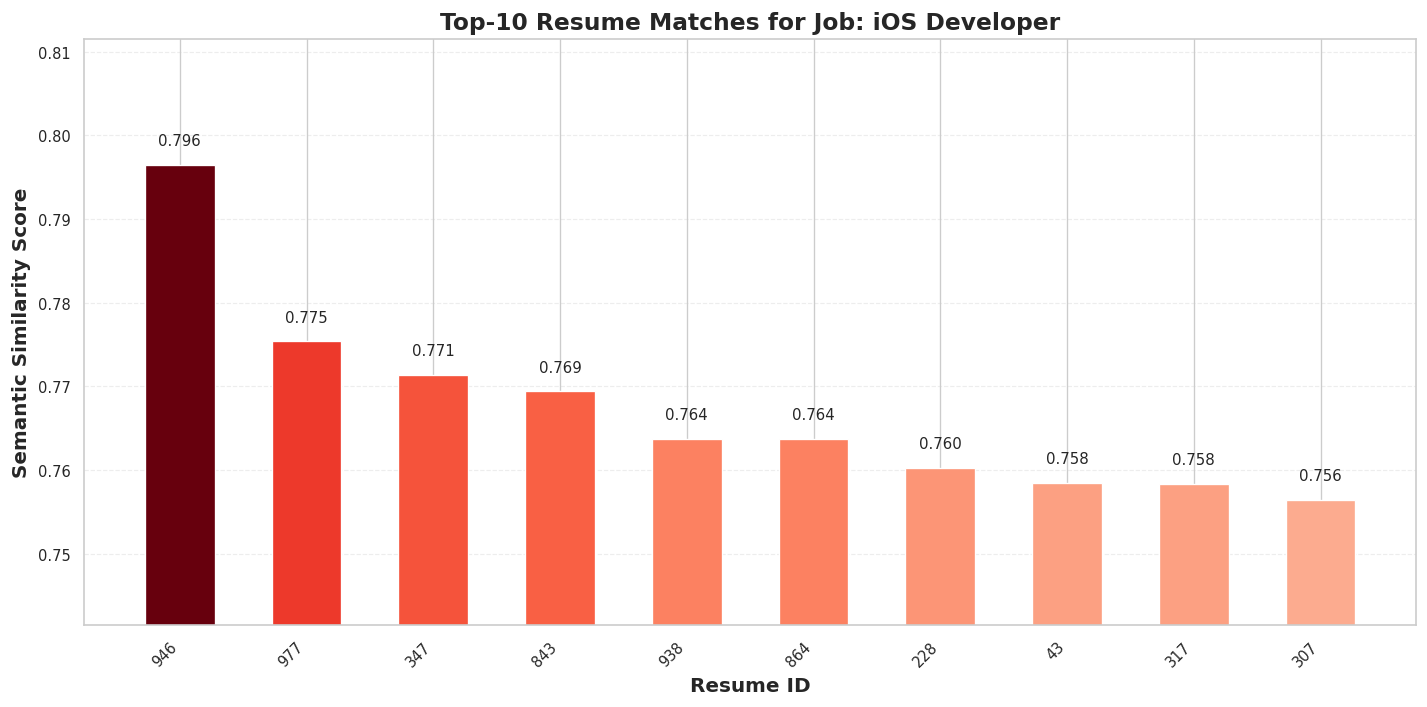

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

plt.figure(figsize=(12,6))

vals = ranking_df["Similarity"].values
norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-6)

cmap = cm.Reds 
colors = [cmap(0.3 + v*0.7) for v in norm]  

bars = plt.bar(
    ranking_df["ResumeID"].astype(str),
    ranking_df["Similarity"],
    width=0.55,
    color=colors
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.002,
        f"{yval:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(
    max(ranking_df["Similarity"].min() - 0.015, 0.70),
    ranking_df["Similarity"].max() + 0.015
)

plt.xlabel("Resume ID", fontsize=12, fontweight='semibold')
plt.ylabel("Semantic Similarity Score", fontsize=12, fontweight='semibold')
plt.title(f"Top-10 Resume Matches for Job: {job_title}", fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)

plt.tight_layout()
plt.show()


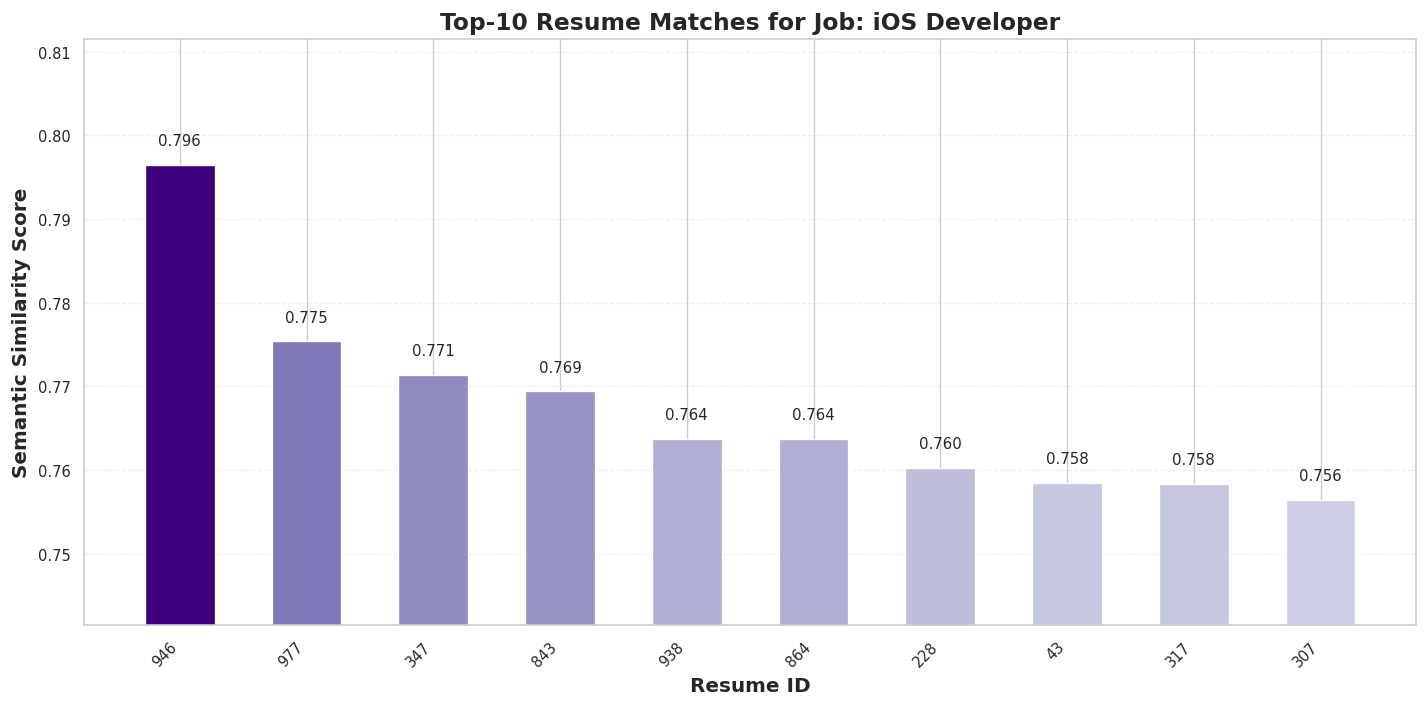

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

plt.figure(figsize=(12,6))

vals = ranking_df["Similarity"].values
norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-6)

cmap = cm.Purples  
colors = [cmap(0.3 + v*0.7) for v in norm]  

bars = plt.bar(
    ranking_df["ResumeID"].astype(str),
    ranking_df["Similarity"],
    width=0.55,
    color=colors
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.002,
        f"{yval:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(
    max(ranking_df["Similarity"].min() - 0.015, 0.70),
    ranking_df["Similarity"].max() + 0.015
)

plt.xlabel("Resume ID", fontsize=12, fontweight='semibold')
plt.ylabel("Semantic Similarity Score", fontsize=12, fontweight='semibold')
plt.title(f"Top-10 Resume Matches for Job: {job_title}", fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)

plt.tight_layout()
plt.show()

Data points collected: 10000


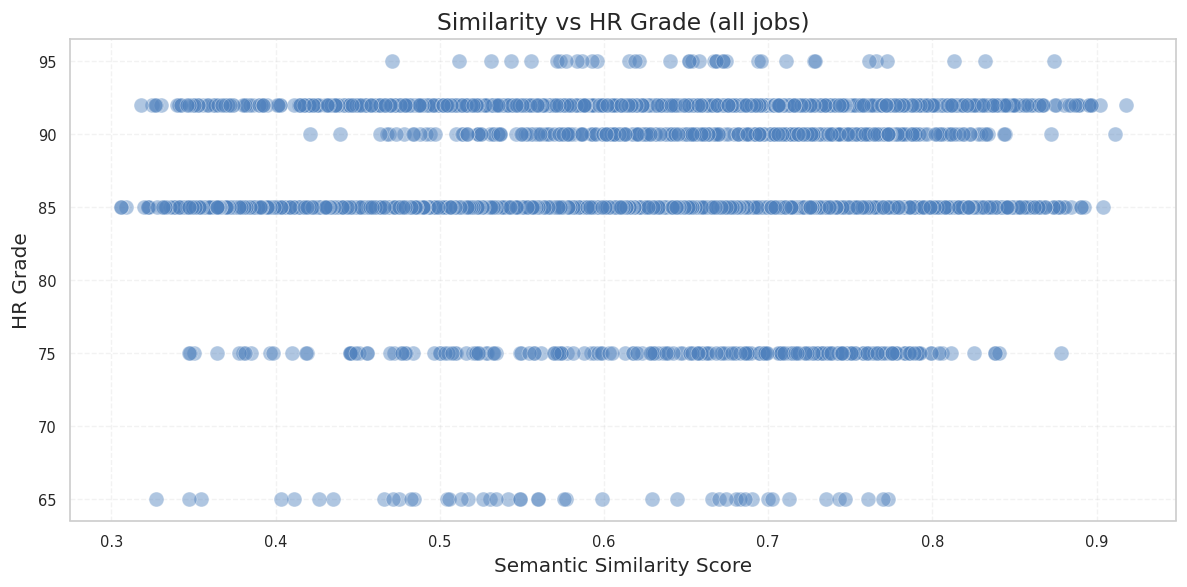

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

TOP_K = 20   

similarity_grade_pairs = []

for i, row in jobs_df.iterrows():
    job_desc = str(row["JobDescription"])

    ranking = rank_resumes_for_job(job_desc, top_k=TOP_K)

    merged = pd.merge(
        ranking,
        resumes_df[["ID", "Grade"]],
        left_on="ResumeID",
        right_on="ID",
        how="inner",
    ).dropna(subset=["Grade"])

    for _, r in merged.iterrows():
        similarity_grade_pairs.append((float(r["Similarity"]), float(r["Grade"])))

all_sims = np.array([p[0] for p in similarity_grade_pairs], dtype=float)
all_grades = np.array([p[1] for p in similarity_grade_pairs], dtype=float)

print(f"Data points collected: {len(all_sims)}")

plt.figure(figsize=(10,5))

plt.scatter(
    all_sims,
    all_grades,
    alpha=0.45,
    color="#4F81BD",        
    edgecolor="white",
    linewidth=0.4,
    s=80
)

plt.xlabel("Semantic Similarity Score", fontsize=12)
plt.ylabel("HR Grade", fontsize=12)
plt.title("Similarity vs HR Grade (all jobs)", fontsize=14)

plt.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()



## 7) WEIGHTED RANKING
and
## 8) CEO LEVEL FINAL DECISION

,ResumeID,Similarity,Grade,CombinedScore,Explanation
0,946,0.7965,85.0,0.932486,"Candidate 946 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.80. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, an..."
1,977,0.7754,75.0,0.597369,"Candidate 977 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.78. The HR-assigned grade (75.0/100) indicates good resume quality, experience depth, an..."
2,347,0.7714,85.0,0.587370,"Candidate 347 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.77. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, an..."
3,843,0.7694,85.0,0.559871,"Candidate 843 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.77. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, an..."
4,864,0.7637,92.0,0.512998,"Candidate 864 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.76. The HR-assigned grade (92.0/100) indicates good resume quality, experience depth, an..."
5,938,0.7637,85.0,0.481498,"Candidate 938 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.76. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, an..."
6,317,0.7584,92.0,0.440124,"Candidate 317 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.76. The HR-assigned grade (92.0/100) indicates good resume quality, experience depth, an..."
7,228,0.7603,85.0,0.434749,"Candidate 228 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.76. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, an..."
8,307,0.7565,92.0,0.414000,"Candidate 307 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.76. The HR-assigned grade (92.0/100) indicates good resume quality, experience depth, an..."
9,43,0.7585,85.0,0.409999,"Candidate 43 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.76. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, and..."



================ CEO FINAL DECISION ================

Selected Resume ID : 946
Semantic Similarity: 0.796
HR Grade           : 85.0/100
Combined Score     : 0.932

Decision Justification:
Candidate 946 demonstrates strong alignment with the job requirements, reflected in a similarity score of 0.80. The HR-assigned grade (85.0/100) indicates good resume quality, experience depth, and suitability for IT roles. Combining relevance and quality, the candidate attains a weighted score of 0.932, positioning them as a top fit for shortlisting.


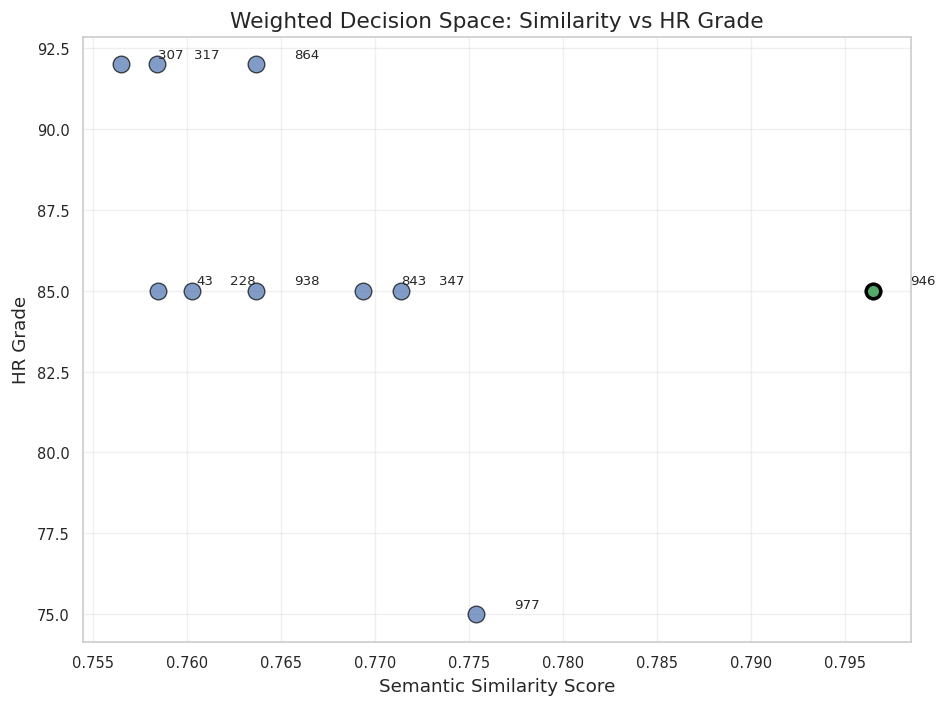

In [ ]:
ranking_df["ResumeID"] = ranking_df["ResumeID"].astype(int)
resumes_df["ID"] = resumes_df["ID"].astype(int)

shortlist = ranking_df.merge(
    resumes_df[["ID", "Grade"]],
    left_on="ResumeID",
    right_on="ID",
    how="inner"
)

sim = shortlist["Similarity"].astype(float)
shortlist["Similarity_norm"] = (sim - sim.min()) / (sim.max() - sim.min() + 1e-6)
shortlist["Grade_norm"] = shortlist["Grade"].astype(float) / 100.0

W_SIM = 0.55    
W_GRADE = 0.45 

shortlist["CombinedScore"] = (
    W_SIM * shortlist["Similarity_norm"] +
    W_GRADE * shortlist["Grade_norm"]
)

shortlist_sorted = shortlist.sort_values(
    by="CombinedScore",
    ascending=False
).reset_index(drop=True)

def explain_candidate(row):
    msg = (
        f"Candidate {int(row.ResumeID)} demonstrates strong alignment with the job "
        f"requirements, reflected in a similarity score of {row.Similarity:.2f}. "
        f"The HR-assigned grade ({row.Grade:.1f}/100) indicates good resume quality, "
        f"experience depth, and suitability for IT roles. "
        f"Combining relevance and quality, the candidate attains a weighted score "
        f"of {row.CombinedScore:.3f}, positioning them as a top fit for shortlisting."
    )
    return msg

shortlist_sorted["Explanation"] = shortlist_sorted.apply(
    explain_candidate, axis=1
)

display(
    shortlist_sorted[
        ["ResumeID", "Similarity", "Grade", "CombinedScore", "Explanation"]
    ].head(10)
)


# 8) CEO Final Selection

final_candidate = shortlist_sorted.iloc[0]

print("\n================ CEO FINAL DECISION ================\n")
print(f"Selected Resume ID : {int(final_candidate.ResumeID)}")
print(f"Semantic Similarity: {final_candidate.Similarity:.3f}")
print(f"HR Grade           : {final_candidate.Grade:.1f}/100")
print(f"Combined Score     : {final_candidate.CombinedScore:.3f}\n")

print("Decision Justification:")
print(final_candidate.Explanation)


plt.figure(figsize=(8,6))
plt.scatter(
    shortlist_sorted["Similarity"],
    shortlist_sorted["Grade"],
    s=100, edgecolor="black", alpha=0.7
)


plt.scatter(
    final_candidate["Similarity"],
    final_candidate["Grade"],
    s=300,
    edgecolor="black",
    linewidth=2,
    marker="."
)

for _, r in shortlist_sorted.iterrows():
    plt.text(
        r["Similarity"] + 0.002,
        r["Grade"] + 0.2,
        str(int(r["ResumeID"])),
        fontsize=8
    )

plt.xlabel("Semantic Similarity Score", fontsize=11)
plt.ylabel("HR Grade", fontsize=11)
plt.title("Weighted Decision Space: Similarity vs HR Grade", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
